### **1. 라이브러리 호출**

In [73]:
import numpy as np
import pandas as pd
from IPython.display import display
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
import platform


warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

### **2. 데이터 전처리**

In [74]:
# 데이터 확인

df_shorts = pd.read_csv("../../data/results/preprocessed/fnb_shorts_df.csv", encoding='utf-8')

print(df_shorts.columns.tolist())
print('='*60)
print(df_shorts.info())

['video_id', 'title', 'channel_id', 'channel_title', 'description', 'upload_date', 'tags', 'view_count', 'like_count', 'comment_count', 'duration', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', 'subscriber_count', 'domain', 'description_missing_flag', 'tags_missing_flag', 'er', 'ler', 'cer', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd']
<class 'pandas.DataFrame'>
RangeIndex: 6942 entries, 0 to 6941
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   video_id                    6942 non-null   str    
 1   title                       6942 non-null   str    
 2   channel_id                  6942 non-null   str    
 3   channel_title               694

In [75]:
# 데이터 타입 변환
df_shorts['upload_date'] = pd.to_datetime(df_shorts['upload_date']).dt.tz_localize(None)

# 확인
print(df_shorts['upload_date'].dtype) # datetime64[us]
print(df_shorts['upload_date'].head(1)) # 2026-04-24 09:00:31

datetime64[us]
0   2026-04-24 09:00:31
Name: upload_date, dtype: datetime64[us]


### **3. 파생변수 제작 및 데이터 필터링**

In [76]:
# 수집 마지막 날짜를 기준점으로 설정 (경과 일 수 계산 기준)
REFERENCE_DATE = pd.Timestamp("2026-04-27")

# 기준일 - 업로드일 = 영상업로드 후 경과일
df_shorts['elapsed_days'] = (REFERENCE_DATE - df_shorts['upload_date']).dt.days

# 업로드 당일 수집된 영상은 경과일이 0이 되어 RR 계산 시 분모가 0이 됨 -> NaN 처리
df_shorts['elapsed_days'] = df_shorts['elapsed_days'].replace(0, float('nan'))

In [77]:
# 분석 대상 영상 필터링-1 (2021.10.13 ~ 2026.03.27)
ANALYSIS_START = pd.Timestamp("2021-10-13")
ANALYSIS_END = pd.Timestamp("2026-03-27")

df_target = df_shorts[
    (df_shorts['upload_date'] >= ANALYSIS_START)&
    (df_shorts['upload_date'] <= ANALYSIS_END)
].copy()

print(df_target.info())

<class 'pandas.DataFrame'>
Index: 6613 entries, 11 to 6941
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    6613 non-null   str           
 1   title                       6613 non-null   str           
 2   channel_id                  6613 non-null   str           
 3   channel_title               6613 non-null   str           
 4   description                 6613 non-null   str           
 5   upload_date                 6613 non-null   datetime64[us]
 6   tags                        6613 non-null   str           
 7   view_count                  6613 non-null   int64         
 8   like_count                  6613 non-null   float64       
 9   comment_count               6613 non-null   float64       
 10  duration                    6613 non-null   float64       
 11  definition                  6613 non-null   str           
 12  license

In [78]:
# 분석 대상 영상 필터링-2 (조회수 하위 5% 영상 제거)
view_cnt_5pct = df_target['view_count'].quantile(0.05)

df_target_main = df_target[df_target['view_count']>view_cnt_5pct].copy()

print(f"하위 5% 영상의 조회수: {view_cnt_5pct}")
print('='*60)
print(df_target_main.info())

하위 5% 영상의 조회수: 336.0
<class 'pandas.DataFrame'>
Index: 6281 entries, 11 to 6941
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    6281 non-null   str           
 1   title                       6281 non-null   str           
 2   channel_id                  6281 non-null   str           
 3   channel_title               6281 non-null   str           
 4   description                 6281 non-null   str           
 5   upload_date                 6281 non-null   datetime64[us]
 6   tags                        6281 non-null   str           
 7   view_count                  6281 non-null   int64         
 8   like_count                  6281 non-null   float64       
 9   comment_count               6281 non-null   float64       
 10  duration                    6281 non-null   float64       
 11  definition                  6281 non-null   str   

In [79]:
# RR 계산
# (총 조회수/업로드 후 경과일수)/구독자수

df_target_main['RR'] = (df_target_main['view_count']/df_target_main['elapsed_days']) / df_target_main['subscriber_count']

In [80]:
channel_cnt = df_target_main['channel_id'].value_counts()

print(f"\n채널 수: {df_target_main['channel_id'].nunique()}")
print(f"\n[채널별 영상 수]\n{channel_cnt}")


채널 수: 61

[채널별 영상 수]
channel_id
UCl0HemfAt7dShJRf59_cuGQ    683
UCsM07dUwo0WOWhFbVsG8K6A    540
UCaxvyTYdWaDXupmgj5ttDUQ    447
UCSQ0lVqv57JVw1lOdJ2vTVA    445
UCC3eqZIo6lqZQQAN9MO0LQA    390
UCnL1m_iPeN8vX7zFHoB4SYg    256
UCHvCHuXTg6yfQQ1QCeDQMLg    242
UCFXwXfbr4b1HHl-YKCOaydA    239
UCzGara7SUTKXruclCD4eA5g    193
UCbEEgpyRxXd6rbM_xhApb_Q    164
UC-WFvgdXXmZPj4pDI8GFbzQ    162
UCfv1dkNKCFUtZouvp3DhS3g    152
UCDryA2PIGnbs9NYn_63rISw    147
UCt0Pnki9ZDDYx6auEtClYLQ    142
UCzCxSb_RYZuaiaP3u9QNR_A    131
UC4xGgCpoPfLHcuPeUbnMibA    121
UCzGbclHB9ZcrbcV4qg11C1A    102
UC-9HdRV-OzriZ1Q09bT304w     93
UCzKFT7cBIKO9Dapikf6e3ow     92
UCpvT-53Ki7d9Z0PWKC6fGOA     88
UCIAFN5e9KzBu_F3dBDbmmVg     82
UCuJkoRqYKKCwagZhmz6my-g     80
UCOV_BpGzvmH7ZtjQOWg0bSQ     78
UClgbMkn177O0xNOEcR9rtug     74
UChD4kH8BcI49njXGL5-makg     72
UC9Hu-7OguU6HyWaxP_GBYcA     72
UCtAHe2OINYIyGOTLDSCzFFg     71
UCGmLtNZFTL6PiKsz3Vpdgbw     70
UCEKRI0fipK4LEgV98nI2CQA     64
UCmvqXRPTfMgkKF3MFWylMqQ     63
UCPz4i6

In [81]:
print(f"영상 10개 미만 채널 수: {(channel_cnt < 10).sum()}개")
print(f"영상 10개 이상 채널 수: {(channel_cnt >= 10).sum()}개")
print(f"\n[영상 수 통계]\n{channel_cnt.describe()}")

영상 10개 미만 채널 수: 10개
영상 10개 이상 채널 수: 51개

[영상 수 통계]
count     61.000000
mean     102.967213
std      138.138212
min        1.000000
25%       16.000000
50%       55.000000
75%      121.000000
max      683.000000
Name: count, dtype: float64


In [82]:
# 구간별 채널 수 및 채널 비율 확인
total_channels = len(channel_cnt)

for threshold in [5, 10, 15, 20]:
    below_channels = (channel_cnt < threshold).sum()
    above_channels = (channel_cnt >= threshold).sum()
    below_pct = below_channels / total_channels * 100

    print(f"기준 {threshold:2d}개 → "
          f"기준 미만: {below_channels}개 채널 ({below_pct:.1f}%) / "
          f"기준 이상: {above_channels}개 채널 ({100 - below_pct:.1f}%)")

기준  5개 → 기준 미만: 5개 채널 (8.2%) / 기준 이상: 56개 채널 (91.8%)
기준 10개 → 기준 미만: 10개 채널 (16.4%) / 기준 이상: 51개 채널 (83.6%)
기준 15개 → 기준 미만: 14개 채널 (23.0%) / 기준 이상: 47개 채널 (77.0%)
기준 20개 → 기준 미만: 16개 채널 (26.2%) / 기준 이상: 45개 채널 (73.8%)


In [83]:
# 컬럼명 변경
df_target_main = df_target_main.rename(columns={
    # 기본 정보
    'channel_title'    : '채널명',
    'upload_date'      : '업로드일시',
    'duration'         : '영상길이(초)',

    # 수치 지표
    'view_count'       : '조회수',
    'like_count'       : '좋아요수',
    'comment_count'    : '댓글수',
    'subscriber_count' : '구독자수',

    # 파생 지표
    'elapsed_days'     : '경과일수',
    'RR'               : '도달률(RR)',       # Reach Rate
    'er'               : '참여율(ER)',       # Engagement Rate
    'ler'              : '조회수 대비 좋아요율',     # Like Engagement Rate
    'cer'              : '조회수 대비 댓글률',       # Comment Engagement Rate
})

# 결과 확인
pprint(df_target_main.columns.tolist())

['video_id',
 'title',
 'channel_id',
 '채널명',
 'description',
 '업로드일시',
 'tags',
 '조회수',
 '좋아요수',
 '댓글수',
 '영상길이(초)',
 'definition',
 'license',
 'embeddable',
 'has_paid_product_placement',
 'thumbnail',
 'caption',
 'final_url',
 'instream_type',
 'channel_handle',
 'channel_tier',
 '구독자수',
 'domain',
 'description_missing_flag',
 'tags_missing_flag',
 '참여율(ER)',
 '조회수 대비 좋아요율',
 '조회수 대비 댓글률',
 'wei',
 'description_length',
 'category_name',
 'upload_year',
 'upload_month',
 'upload_dayofweek',
 'upload_hour',
 'tags_count',
 'upload_quarter',
 'upload_ym_quarter',
 'upload_ymd',
 '경과일수',
 '도달률(RR)']


In [84]:
# 일평균 조회수 = 조회수 / 경과일수
df_target_main['일평균 조회수'] = df_target_main['조회수'] / df_target_main['경과일수']

# 결과 확인
print(df_target_main['일평균 조회수'].describe())

count      6281.000000
mean       1355.442497
std       14352.189187
min           0.236364
25%           4.945600
50%          32.433333
75%         184.901836
max      673653.156250
Name: 일평균 조회수, dtype: float64


---
### 4. 지표 1
- ER과 RR을 활용하는 지표
- 가중치를 구하는 방법 (후보)
    - CV 기반 ✅ 채택
        - 두 지표가 독립적이라는 가정 하에 CV값이 더 큰 값이 영상간의 차이를 변별하기 좋을 것이기 때문에 더 높은 가중치 부여
    - PCA 기반 ❌ 불가
        - RR과 ER을 PCA에 넣었을 때, 전체 분산을 가장 잘 설명하는 첫번째 주성분(PC1)에서 각 변수의 기여도(loading)를
        w1, w2로 사용하는 방법
        - 변수가 2개일 때 표준화된 데이터에서 PC1의 loading² + PC2의 loading²이
          항상 동일하게 나와 수학적으로 가중치 차별화가 불가능

In [85]:
# -------------------------------------------------------
# CV(변동계수) 기반 채널별 가중치(w1, w2) 산출
# RR과 ER 중 채널 내 영상 간 변별력이 높은 지표에 높은 가중치 부여
# -------------------------------------------------------
channel_weights = {} # 채널별 가중치

for channel_id, group in df_target_main.groupby('channel_id'):

    # 영상 10개 미만 채널은 CV 계산이 불안정하므로 균등 가중치 적용 (영상 개수는 협의 필요)
    if len(group) < 10:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    # CV = 표준편차 / 평균
    # CV가 클수록 영상 간 차이를 더 잘 변별하는 지표
    cv_rr = group['도달률(RR)'].std() / group['도달률(RR)'].mean()
    cv_er = group['참여율(ER)'].std() / group['참여율(ER)'].mean()
    cv_sum = cv_rr + cv_er

    # cv_sum이 0인 경우 (모든 영상의 RR, ER이 동일) 균등 가중치 적용
    if cv_sum == 0:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    channel_weights[channel_id] = {
        'w1': cv_rr / cv_sum,  # RR의 변별력 비율
        'w2': cv_er / cv_sum   # ER의 변별력 비율
    }

# 딕셔너리 → DataFrame으로 변환 (행: channel_id, 열: w1, w2)
channel_weights_df = pd.DataFrame(channel_weights).T
channel_weights_df.index.name = 'channel_id'

# 확인
print(f"[채널별 가중치]")
print(channel_weights_df)
print(f"\n[가중치 통계]")
print(channel_weights_df.describe())
print(f"\n균등 가중치 적용 채널 수: {(channel_cnt < 10).sum()}개")

[채널별 가중치]
                                w1        w2
channel_id                                  
UC-9HdRV-OzriZ1Q09bT304w  0.703220  0.296780
UC-WFvgdXXmZPj4pDI8GFbzQ  0.759785  0.240215
UC4xGgCpoPfLHcuPeUbnMibA  0.896796  0.103204
UC88W-nkd_7G9S7u-2xlX4DQ  0.736658  0.263342
UC9Hu-7OguU6HyWaxP_GBYcA  0.648685  0.351315
UC9_GC5aoZJMz5MAH9e8x9Yg  0.500000  0.500000
UCC-RQrzmKSAV70txxsdXWqQ  0.451196  0.548804
UCC3eqZIo6lqZQQAN9MO0LQA  0.632615  0.367385
UCDjdk0ufvcvV08hAm_vF06Q  0.712071  0.287929
UCDryA2PIGnbs9NYn_63rISw  0.795757  0.204243
UCEKRI0fipK4LEgV98nI2CQA  0.846932  0.153068
UCFRMEa0vlRfrgcQpnryE-TA  0.643236  0.356764
UCFXwXfbr4b1HHl-YKCOaydA  0.704001  0.295999
UCG_gfzGVpsxGwYuFgH8-tNA  0.500000  0.500000
UCGmLtNZFTL6PiKsz3Vpdgbw  0.626494  0.373506
UCHvCHuXTg6yfQQ1QCeDQMLg  0.772953  0.227047
UCIAFN5e9KzBu_F3dBDbmmVg  0.490857  0.509143
UCMqZKRBemgZ0_1uLT2yAF9w  0.520428  0.479572
UCOV_BpGzvmH7ZtjQOWg0bSQ  0.830527  0.169473
UCOx-g_rEMW3oD8g-bQaLWkQ  0.500000  0.500000


In [86]:
# 가중치의 평균값 적용
# 다양한 채널의 특성을 반영했으면서도 모든 영상에 동일한 기준을 적용하면 다른 채널의 영상끼리도 비교하기 좋을 것 같음
w1 = channel_weights_df['w1'].mean()
w2 = channel_weights_df['w2'].mean()

print(f"w1 (RR 가중치): {w1:.4f}") # w1 (RR 가중치): 0.6688
print(f"w2 (ER 가중치): {w2:.4f}") # w2 (ER 가중치): 0.3312

w1 (RR 가중치): 0.6688
w2 (ER 가중치): 0.3312


In [87]:
# 전체 영상을 기준으로 백분위 계산
# rank(pct=True): 0~1 사이 백분위로 변환
df_target_main['RR_백분위'] = df_target_main['도달률(RR)'].rank(pct=True)
df_target_main['ER_백분위'] = df_target_main['참여율(ER)'].rank(pct=True)

# score1 = w1 * RR백분위 + w2 * ER백분위
# 0~1 사이 값, 높을수록 성과가 좋은 영상
df_target_main['score1'] = (
    w1 * df_target_main['RR_백분위'] + w2 * df_target_main['ER_백분위']
)

# 결과 확인
print(f"[score1 통계]")
print(df_target_main['score1'].describe())
print(f"\n[RR_백분위 통계]")
print(df_target_main['RR_백분위'].describe())
print(f"\n[ER_백분위 통계]")
print(df_target_main['ER_백분위'].describe())

[score1 통계]
count    6281.000000
mean        0.500080
std         0.171830
min         0.073335
25%         0.359515
50%         0.508872
75%         0.635689
max         0.970780
Name: score1, dtype: float64

[RR_백분위 통계]
count    6281.000000
mean        0.500080
std         0.288698
min         0.000159
25%         0.250119
50%         0.500080
75%         0.750040
max         1.000000
Name: RR_백분위, dtype: float64

[ER_백분위 통계]
count    6281.000000
mean        0.500080
std         0.288698
min         0.000557
25%         0.250119
50%         0.500080
75%         0.750040
max         1.000000
Name: ER_백분위, dtype: float64


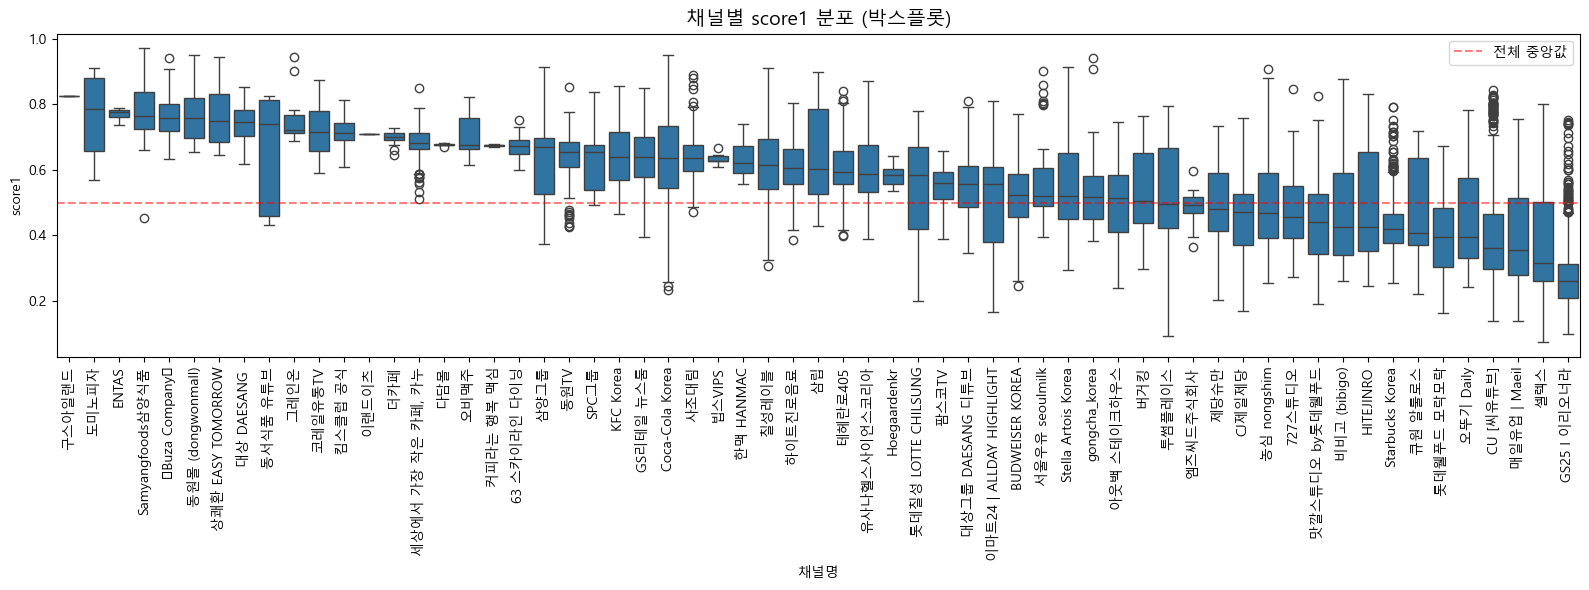

In [88]:
# 채널별 score1 분포 비교 시각화 (박스플롯)
fig, ax = plt.subplots(figsize=(16, 6))

# 채널별 score1 중앙값 기준으로 정렬
channel_order = (
    df_target_main.groupby('채널명')['score1']
    .median()
    .sort_values(ascending=False)
    .index
)

# 박스플롯 (이상치 포함 전체 분포)
sns.boxplot(
    data=df_target_main,
    x='채널명', y='score1',
    order=channel_order,
    ax=ax
)
ax.set_title('채널별 score1 분포 (박스플롯)', fontsize=14)
ax.set_xlabel('채널명')
ax.set_ylabel('score1')
ax.tick_params(axis='x', rotation=90)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='전체 중앙값')
ax.legend()

plt.tight_layout()
plt.show()

---
### **5. 지표 2**
- 일평균 조회수, 좋아요율(ler), 댓글률(cer)을 활용하는 지표
- 채널 생성 후 경과 시간에 관계없이 특정 영상이 업로드되기 직전 3개월 동안
  업로드된 영상들의 평균값을 기준으로 해당 영상의 상대적 성과를 측정
- 직전 3개월 참조 영상에서 해당 영상 자신은 제외
- 참조 영상이 0개인 경우 (채널 초기 영상) → 지표 2 계산 제외

- 3가지 성과 지표
    - 조회수 성과 = 해당 영상의 일평균 조회수 / 직전 3개월 영상들의 평균 일평균 조회수
    - 좋아요 성과 = 해당 영상의 좋아요율(ler) / 직전 3개월 영상들의 평균 좋아요율
    - 댓글 성과  = 해당 영상의 댓글률(cer) / 직전 3개월 영상들의 평균 댓글률

- 가중치를 구하는 방법 (후보)
    - CV 기반
        - 3가지 성과 지표 각각의 CV를 구해서 변별력이 높은 지표에 높은 가중치 부여
    - PCA 기반
        - 변수가 3개이므로 PC1의 loading을 가중치로 사용 가능
        - CV 기반과 비교 후 선택

In [89]:
# 같은 채널에서 같은 날 업로드된 영상 확인
# 직전 3개월 참조 그룹 계산 시 동일 날짜 처리 방침 결정을 위해
same_day = df_target_main.groupby(['channel_id', 'upload_ymd']).size()
same_day = same_day[same_day > 1]

print(f"같은 날 2개 이상 업로드된 경우: {len(same_day)}건") # 908건

같은 날 2개 이상 업로드된 경우: 908건


In [90]:
# 채널별 같은 날 2개 이상 업로드된 건수 확인
same_day_by_channel = (
    df_target_main.groupby(['channel_id', 'upload_ymd']).size()
    .reset_index(name='daily_count')
)

# 하루에 2개 이상 업로드된 날만 필터링
same_day_by_channel = same_day_by_channel[same_day_by_channel['daily_count'] > 1]

# 채널별 집계
same_day_summary = (
    same_day_by_channel.groupby('channel_id')
    .agg(
        중복업로드_날짜수=('upload_ymd', 'count'),
        중복업로드_최대=('daily_count', 'max')
    )
    .reset_index()
)

# 채널명 붙이기
same_day_summary = same_day_summary.merge(
    df_target_main[['channel_id', '채널명']].drop_duplicates(),
    on='channel_id'
)

# 결과 데이터 프레임
result = (
    same_day_summary[['채널명', '중복업로드_날짜수', '중복업로드_최대']]
    .sort_values('중복업로드_날짜수', ascending=False)
    .reset_index(drop=True)
)

print(f"같은 날 2개 이상 업로드한 채널 수: {len(same_day_summary)}개")
print(f"\n[채널별 중복 업로드 현황]")
display(result)

같은 날 2개 이상 업로드한 채널 수: 50개

[채널별 중복 업로드 현황]


,채널명,중복업로드_날짜수,중복업로드_최대
0,GS25 l 이리오너라,135,5
1,이마트24 | ALLDAY HIGHLIGHT,93,7
2,Starbucks Korea,77,8
3,CU [씨유튜브],67,5
4,CJ제일제당,40,6
5,오뚜기 Daily,39,7
6,동원TV,38,4
7,칠성레이블,38,7
8,Coca-Cola Korea,37,5
9,매일유업 | Maeil,30,5
